# 🎮 Steam Nexus: Data Engineering Pipeline (Games)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PATH_GAMES = "../data/raw/steam_games_raw.csv"
headers_fixed = [
    'AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU', 'Required age',
    'Price', 'DiscountDLC count', 'About the game', 'Supported languages',
    'Full audio languages', 'Reviews', 'Header image', 'Website', 'Support url',
    'Support email', 'Extra_Column', 'Windows', 'Mac', 'Linux', 'Metacritic score',
    'Metacritic url', 'User score', 'Positive', 'Negative', 'Score rank',
    'Achievements', 'Recommendations', 'Notes', 'Average playtime forever',
    'Average playtime two weeks', 'Median playtime forever', 'Median playtime two weeks',
    'Developers', 'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies'
]

df_games = pd.read_csv(PATH_GAMES, low_memory=False, names=headers_fixed, skiprows=1)
print("✅ Dataset loaded for analysis.")

✅ Dataset loaded for analysis.


## 🔍 1. Structural Recognition
Identifying the dataset magnitude and the initial state of data types.

In [2]:
print(f"📏 Dimensions: {df_games.shape[0]} rows x {df_games.shape[1]} columns")
display(df_games.head(3))

📏 Dimensions: 122611 rows x 40 columns


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN


In [3]:
print("\n--- Initial Typing ---")
df_games.info()


--- Initial Typing ---
<class 'pandas.DataFrame'>
RangeIndex: 122611 entries, 0 to 122610
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       122611 non-null  int64  
 1   Name                        122610 non-null  str    
 2   Release date                122611 non-null  str    
 3   Estimated owners            122611 non-null  str    
 4   Peak CCU                    122611 non-null  int64  
 5   Required age                122611 non-null  int64  
 6   Price                       122611 non-null  float64
 7   DiscountDLC count           122611 non-null  int64  
 8   About the game              122611 non-null  int64  
 9   Supported languages         114162 non-null  str    
 10  Full audio languages        122611 non-null  str    
 11  Reviews                     122611 non-null  str    
 12  Header image                12070 non-null   str    
 13  W

In [4]:
df_games.isnull().sum()

AppID                              0
Name                               1
Release date                       0
Estimated owners                   0
Peak CCU                           0
Required age                       0
Price                              0
DiscountDLC count                  0
About the game                     0
Supported languages             8449
Full audio languages               0
Reviews                            0
Header image                  110541
Website                           81
Support url                    72935
Support email                  68469
Extra_Column                   22263
Windows                            0
Mac                                0
Linux                              0
Metacritic score                   0
Metacritic url                118355
User score                         0
Positive                           0
Negative                           0
Score rank                    122571
Achievements                       0
R

In [5]:
print("\n--- Memory Estimation ---")
mem_usage = df_games.memory_usage(deep=True).sum() / (1024**2)
print(f"Total memory used by DataFrame: {mem_usage:.2f} MB")


--- Memory Estimation ---
Total memory used by DataFrame: 558.31 MB


### 1.2 Scale and Composition Analysis
Extending our structural recognition to understand the granularity and dispersion of our data through unique counts and descriptive statistics.

In [6]:
print("\n--- Unique Values Count (Selected Columns) ---")
unique_counts = {
    'AppID': df_games['AppID'].nunique(),
    'Name': df_games['Name'].nunique(),
    'Release date': df_games['Release date'].nunique(),
    'Developers': df_games['Developers'].nunique(),
    'Publishers': df_games['Publishers'].nunique(),
    'Categories': df_games['Categories'].nunique(),
    'Genres': df_games['Genres'].nunique(),
    'Tags': df_games['Tags'].nunique(),
    'Supported languages': df_games['Supported languages'].nunique()
}
for col, count in unique_counts.items():
    print(f"'{col}': {count} unique values")


--- Unique Values Count (Selected Columns) ---
'AppID': 122611 unique values
'Name': 121454 unique values
'Release date': 5081 unique values
'Developers': 70812 unique values
'Publishers': 62684 unique values
'Categories': 13291 unique values
'Genres': 2894 unique values
'Tags': 77179 unique values
'Supported languages': 113556 unique values


In [7]:
print("\n--- Descriptive Statistics (Key Numerical Columns) ---")
df_games_numeric_cols = [
    'Price', 'Estimated owners', 'Peak CCU', 'Required age',
    'Metacritic score', 'Positive', 'Negative', 'Achievements', 'Recommendations',
    'Average playtime forever', 'Median playtime forever'
]

# Convert relevant columns to numeric, coercing errors to NaN
for col in df_games_numeric_cols:
    if col in df_games.columns:
        df_games[col] = pd.to_numeric(df_games[col], errors='coerce')

display(df_games[df_games_numeric_cols].describe().transpose())


--- Descriptive Statistics (Key Numerical Columns) ---


,count,mean,std,min,25%,50%,75%,max
Price,122611.0,4.765091,12.531030,0.0,0.55,2.24,5.24,999.98
Estimated owners,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Peak CCU,122611.0,54.593324,3729.451567,0.0,0.00,0.00,0.00,1013936.00
Required age,122611.0,0.167611,1.653591,0.0,0.00,0.00,0.00,21.00
Metacritic score,122611.0,2.564941,13.660559,0.0,0.00,0.00,0.00,97.00
Positive,122611.0,1044.986135,28091.729937,0.0,0.00,5.00,37.00,7642084.00
Negative,122611.0,169.197429,5374.644880,0.0,0.00,1.00,10.00,1173003.00
Achievements,122611.0,18.087015,141.493879,0.0,0.00,2.00,19.00,9821.00
Recommendations,122611.0,961.824967,21878.803992,0.0,0.00,0.00,0.00,4830455.00
Average playtime forever,122611.0,208.023220,11217.684738,0.0,0.00,0.00,0.00,3429544.00


In [8]:
print("\n--- 'Extra_Column' Verification ---")
if 'Extra_Column' in df_games.columns:
    if df_games['Extra_Column'].isnull().all():
        print("'Extra_Column' is completely empty and can be removed.")
        # df_games = df_games.drop(columns=['Extra_Column']) # Uncomment to remove
    else:
        print("'Extra_Column' contains data. First 5 values:\n", df_games['Extra_Column'].head())
else:
    print("'Extra_Column' not found in DataFrame.")


--- 'Extra_Column' Verification ---
'Extra_Column' contains data. First 5 values:
 0                            NaN
1         support@mangagamer.com
2             support@8floor.net
3          yujingamesc@gmail.com
4    support@realityexpanded.com
Name: Extra_Column, dtype: str


## 🎯 Step 2: Hypothesis and Visualization Based Justification

In this section, we visually demonstrate why we selected each critical variable for our data product.

### 2.1 `Price` Justification (Economic Variable)
**Hypothesis:** Price is not uniform on Steam; there is a clear segmentation between free and premium games that will affect the recommendation system.

**Visual Evidence:**

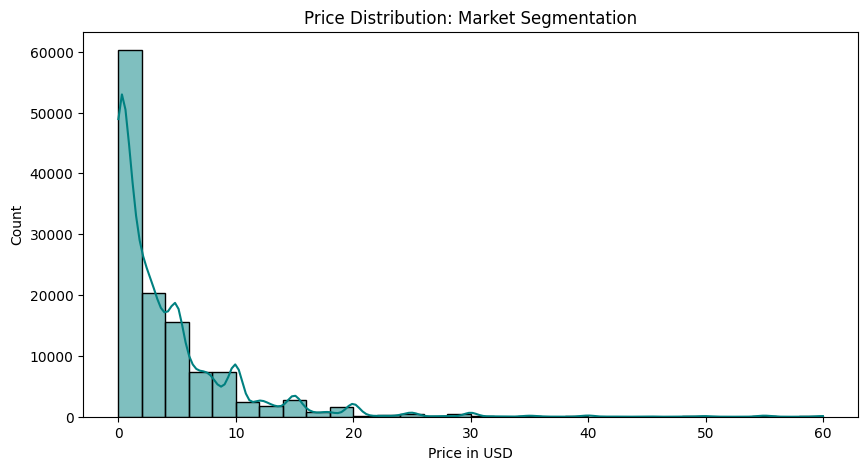

Conclusion: High variability justifies using Price as a segmentation variable.


In [9]:
df_games['Price_num'] = pd.to_numeric(df_games['Price'], errors='coerce').fillna(0.0)
plt.figure(figsize=(10, 5))
sns.histplot(df_games[df_games['Price_num'] < 60]['Price_num'], bins=30, kde=True, color='teal')
plt.title("Price Distribution: Market Segmentation")
plt.xlabel("Price in USD")
plt.show()
print("Conclusion: High variability justifies using Price as a segmentation variable.")

### 2.2 `Genres` / `Tags` Justification (Recommendation Engine)
**Hypothesis:** Most games share multiple tags, allowing for the creation of a co-occurrence network for graph analysis.

**Visual Evidence:**

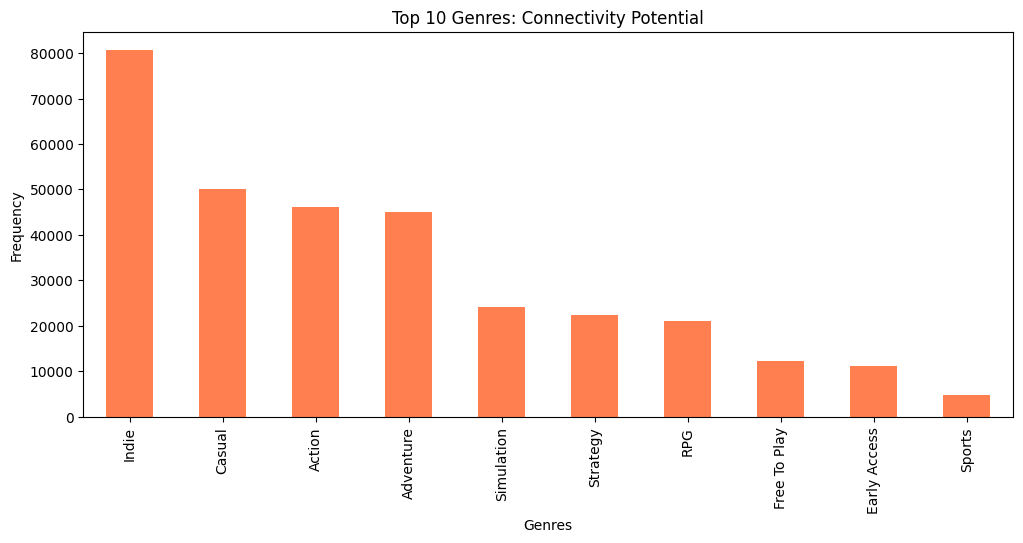

Conclusion: Genre richness justifies the use of Graphs and Clustering.


In [10]:
top_genres = df_games['Genres'].str.split(',').explode().str.strip().value_counts().head(10)
plt.figure(figsize=(12, 5))
top_genres.plot(kind='bar', color='coral')
plt.title("Top 10 Genres: Connectivity Potential")
plt.ylabel("Frequency")
plt.show()
print("Conclusion: Genre richness justifies the use of Graphs and Clustering.")

### 2.3 `Positive` / `Negative` Justification (Success Metrics)
**Hypothesis:** The volume of positive reviews correlates with popularity, allowing for the classification of successful games.

**Visual Evidence:**

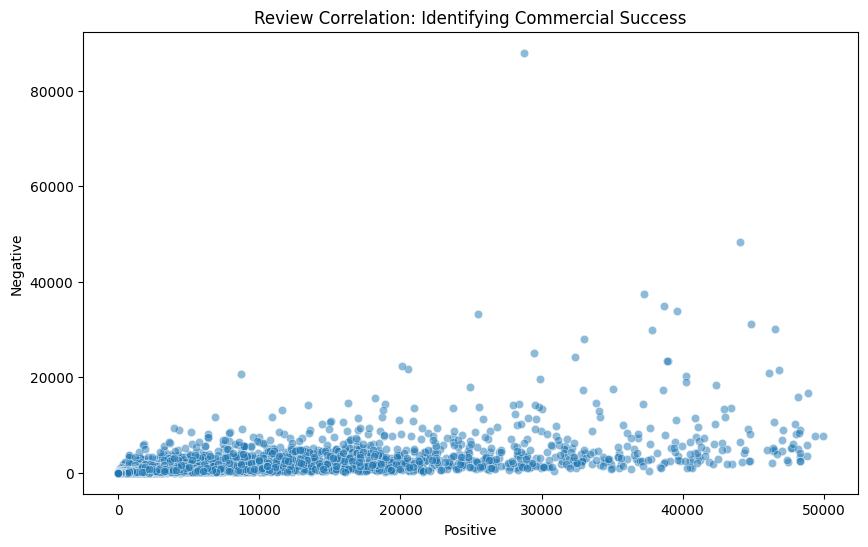

Conclusion: These metrics will allow us to label 'success' for predictive models.


In [11]:
df_games['Positive'] = pd.to_numeric(df_games['Positive'], errors='coerce').fillna(0)
df_games['Negative'] = pd.to_numeric(df_games['Negative'], errors='coerce').fillna(0)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Positive', y='Negative', data=df_games[df_games['Positive'] < 50000], alpha=0.5)
plt.title("Review Correlation: Identifying Commercial Success")
plt.show()
print("Conclusion: These metrics will allow us to label 'success' for predictive models.")

### 2.4 `Name` and `About the game` Justification (Identification and Content)
**Hypothesis:** The name is a key identifier for each game, and its description (About the game) offers valuable textual content for natural language processing models and content-based game recommendations. Cleaning these variables is crucial to ensure their consistency and utility.

**Visual Evidence:**

Games with duplicate names (before cleaning): 1156


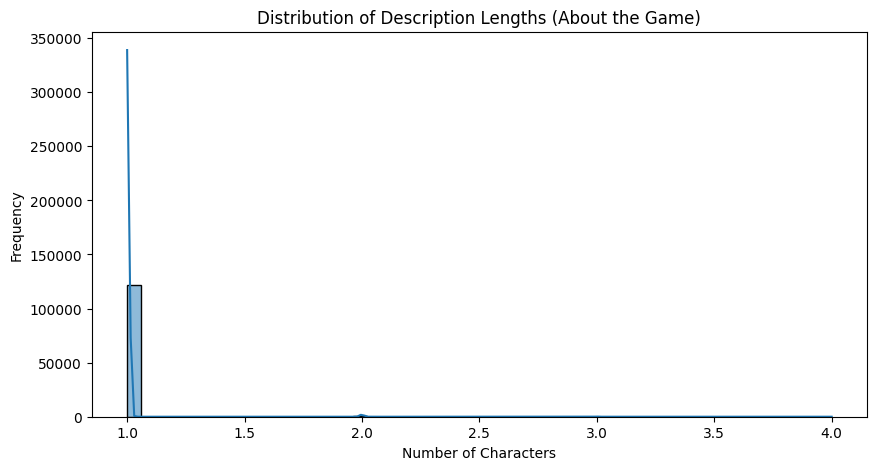


Summary statistics of description length:
count    122611.000000
mean          1.007063
std           0.089580
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: About_the_game_length, dtype: float64
Empty descriptions: 0.00%
Conclusion: Variable description length indicates information richness, useful for NLP. Name uniqueness is vital.


In [22]:
#Duplicate analysis for Name
name_duplicates = df_games[df_games['Name'].notnull()].duplicated(subset=['Name']).sum()
print(f"Games with duplicate names (before cleaning): {name_duplicates}")

#Cleaning Name
df_games['Name'] = df_games['Name'].astype(str).str.strip()

#Cleaning About the game
df_games['About the game'] = df_games['About the game'].fillna('').astype(str).str.strip()

#Description length
df_games['About_the_game_length'] = df_games['About the game'].str.len()

#Visualization
plt.figure(figsize=(10, 5))
sns.histplot(df_games['About_the_game_length'], bins=50, kde=True)
plt.title('Distribution of Description Lengths (About the Game)')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()

#Summary stats
print("\nSummary statistics of description length:")
print(df_games['About_the_game_length'].describe())

#Percentage of empty descriptions
empty_desc = (df_games['About the game'] == '').mean() * 100
print(f"Empty descriptions: {empty_desc:.2f}%")

print("Conclusion: Variable description length indicates information richness, useful for NLP. Name uniqueness is vital.")

### 2.5 `Developers` Justification (Development Impact and Trends)
**Hypothesis:** Developer identity is a key factor in the quantity of games produced and can influence the type and quality of games released, allowing for the identification of prolific or specialized developers and the analysis of industry trends. This is fundamental for understanding the game ecosystem and for recommendation systems that group games by creator.

C:\Users\jorge\AppData\Local\Temp\ipykernel_21160\1846020677.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_developers.index, y=top_developers.values, palette='plasma')


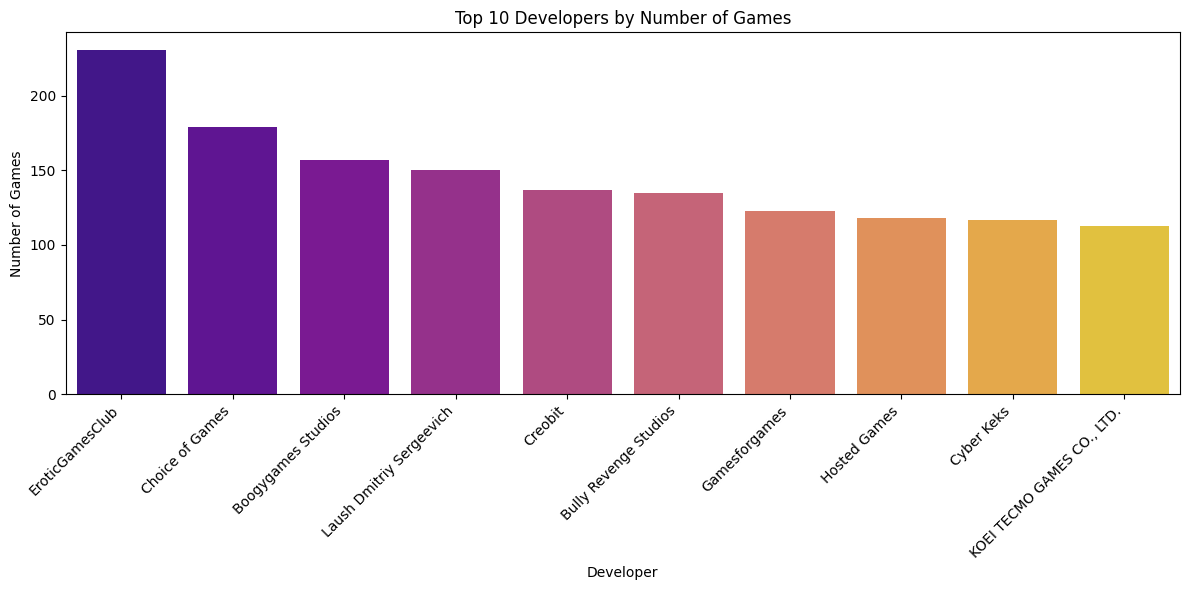

Conclusion: The existence of developers with multiple titles justifies analyzing their impact and creating profiles for recommendations or market analysis.


In [20]:
# Count number of games per developer (excluding 'unknown')
top_developers = df_games[df_games['Developers'] != 'unknown']['Developers'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_developers.index, y=top_developers.values, palette='plasma')
plt.title('Top 10 Developers by Number of Games')
plt.xlabel('Developer')
plt.ylabel('Number of Games')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Conclusion: The existence of developers with multiple titles justifies analyzing their impact and creating profiles for recommendations or market analysis.")

## 🛠️ Step 3: Cleaning and Working Table Creation
After justifying the variables, we generate the final clean dataset.

In [23]:
columns_selected = ['AppID', 'Name', 'Price', 'Genres', 'Tags', 'Positive', 'Negative', 'Release date', 'About the game', 'Developers']
df_game_work = df_games[columns_selected].copy()

In [24]:
df_game_work.head()

,AppID,Name,Price,Genres,Tags,Positive,Negative,Release date,About the game,Developers
0,2539430,Black Dragon Mage Playtest,0.00,NaN,NaN,0,0,"Aug 1, 2023",0,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,5.24,Adventure,"Adventure,Visual Novel,Anime,Cute",252,3,"Jul 29, 2016",0,minori
2,1034400,Mystery Solitaire The Black Raven,4.99,Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",21,3,"May 6, 2019",0,Somer Games
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,8.99,"Casual,Indie,Simulation",NaN,0,0,"Oct 31, 2024",1,유진게임즈
4,3631080,Maze Quest VR,4.99,"Action,Early Access",NaN,0,0,"Apr 24, 2025",0,Reality Expanded LLC


In [25]:
print("--- 🚩 Empty and Duplicate Detection ---")
empty_names = df_game_work['Name'].isnull().sum()
duplicates = df_game_work.duplicated(subset=['AppID']).sum()
print(f"Rows without name: {empty_names}")
print(f"Duplicate AppIDs: {duplicates}")

--- 🚩 Empty and Duplicate Detection ---
Rows without name: 1
Duplicate AppIDs: 0


In [26]:
df_game_work.isnull().sum()

AppID                 0
Name                  1
Price                 0
Genres             8413
Tags              39265
Positive              0
Negative              0
Release date          0
About the game        0
Developers         8437
dtype: int64

In [27]:
df_game_work.shape

(122611, 10)

In [28]:
df_game_work = df_game_work.dropna(subset=['Name'])
df_game_work = df_game_work.drop_duplicates(subset=['AppID'])

In [30]:
print("\n--- 🔄 Type Normalization and Sanitization ---")

# 1. Price, Positive, and Negative Formatting
df_game_work['Price'] = pd.to_numeric(df_game_work['Price'], errors='coerce').fillna(0.0)
df_game_work['Positive'] = pd.to_numeric(df_game_work['Positive'], errors='coerce').fillna(0)
df_game_work['Negative'] = pd.to_numeric(df_game_work['Negative'], errors='coerce').fillna(0)

# 2. Date Formatting
df_game_work['Release date'] = pd.to_datetime(df_game_work['Release date'], errors='coerce')

# 3. Text Sanitization (Ensuring cast to string before .str)
df_game_work['Name'] = df_game_work['Name'].str.strip().str.title()
df_game_work['Genres'] = df_game_work['Genres'].fillna("Other").str.strip().str.lower()
df_game_work['Tags'] = df_game_work['Tags'].fillna("[]").str.strip().str.lower()
df_game_work['Developers'] = df_game_work['Developers'].fillna("Unknown").str.strip().str.lower()
df_game_work['About the game'] = df_game_work['About the game'].fillna('').str.strip()


--- 🔄 Type Normalization and Sanitization ---


In [32]:
print("✅ Technical cleaning completed.")
print(f"Final shape: {df_game_work.shape[0]} rows × {df_game_work.shape[1]} columns")

✅ Technical cleaning completed.
Final shape: 122610 rows × 10 columns


In [34]:
import os
output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "steam_games_cleaned_v1.csv")
df_game_work.to_csv(output_path, index=False)
print(f"🎉 Success! The clean dataset has been generated.")
print(f"📍 Location: {output_path}")
print(f"📊 Final records ready: {len(df_game_work)}")

🎉 Success! The clean dataset has been generated.
📍 Location: ../data/processed\steam_games_cleaned_v1.csv
📊 Final records ready: 122610
